# Linear model —— Sensitivity analysis (Huber parameter and bandwidth h)


In [ ]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import torch
import warnings
from numpy.random import default_rng
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
# import logging

from argparse import Namespace
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.stats import t, norm
from utl import (generate_dgp_data_with_test_sn, Qt_Linear)

from quantes.linear import joint
from arch.covariance.kernel import Andrews
print(torch.cuda.is_available())
warnings.filterwarnings('ignore', category=RuntimeWarning)


False


In [9]:
args = Namespace(
    tau=0.1,
    dof=4,
    scale_norm= 1,
    scale_t= 1,
    val_pct=0.3,
)

def _truncate_X(X, Y, tau, intercept, standardize, val_pct):
    n = X.shape[0]
    n_val = math.floor(val_pct * n)
    train_idx = list(range(0, n - n_val))
    val_idx = list(range(n - n_val, n))
    q75 = np.quantile(np.abs(X[:, intercept:]), 0.75, axis=0)
    mx = np.max(np.abs(X[:, intercept:]), axis=0)
    vsigma = np.linspace(np.max(q75), np.max(mx), 10)
    bv = Qt_Linear(X[train_idx], Y[train_idx], X[val_idx], Y[val_idx],
                   tau, vsigma, standardize=standardize,
                   intercept=intercept, plot=False)
    X_use = X.copy()
    X_use[:, intercept:] = np.clip(X_use[:, intercept:],
                                   -bv['bvsigma_q'], bv['bvsigma_q'])
    return X_use


def linear_param_sensitivity(m, d, n, mult_grid,
                             n_test=1024, dof=3.5, error_type='normal',
                             delta=None, eta=None, err_scale=None,
                             intercept=True, standardize=True, truncate=True):
    """
    Single repetition (seed=m): Fix n, generate one data, return QAPE with shape=(len(mult_grid), 2):  
         Column 0: h sensitivity: robust fixed as default, h = c * h_default  
         Column 1: Huber sensitivity: h fixed as default, robust = c * robust_default
    """
    if err_scale is None:
        err_scale = args.scale_norm
    n_lag = int(d / 2)
    n_indep = d - n_lag
    X_all, Y_all, Qt, ES, _, beta_true, *_ = generate_dgp_data_with_test_sn(
        n, n_test, d, tau=args.tau, err_dist=error_type, df=dof,
        rho_x=0.8, rho_e=0.9, delta=delta, eta=eta,
        n_lag=n_lag, n_indep=n_indep, err_scale=err_scale, seed=m)
    X = X_all[:n, :]
    Y = Y_all[:n]
    X_test = X_all[-n_test:, :]
    testes = ES[-n_test:]

    X_use = (_truncate_X(X, Y, args.tau, intercept, standardize, args.val_pct)
             if truncate else X.copy())

    lm = joint(X_use.copy(), Y, intercept=intercept)

    h_default = lm.bandwidth(args.tau)
    qrfit = lm.fit(tau=args.tau, h=h_default, kernel='Laplacian',
                   standardize=standardize)
    robust_default =  0.25*np.mean((np.minimum(qrfit['res'], 0) / args.tau) ** 4) ** 0.25 \
        * (n / d / (np.log(n) ** 2)) ** (1 / 6)

    err_h, err_c = [], []
    for c in mult_grid:
        # (1) h Sensitivity: robust fixed = robust_default, h = c * h_default
        res_h = lm.twostep(tau=args.tau, h=c * h_default, loss='Huber',
                           standardize=standardize, robust=robust_default)
        err_h.append(np.quantile(np.abs(testes - X_test @ res_h['coef_e']), 0.95))
        # (2) Huber Sensitivity: h fixed = h_default，robust = c * robust_default
        res_c = lm.twostep(tau=args.tau, h=h_default, loss='Huber',
                           standardize=standardize, robust=c * robust_default)
        err_c.append(np.quantile(np.abs(testes - X_test @ res_c['coef_e']), 0.95))
    return np.c_[err_h, err_c]


def run_linear_sensitivity(M=200, d=30, n=8192, mult_grid=None,
                           n_test=1024, dof=2.25, error_type='normal',
                           err_scale=None, intercept=True, standardize=True,
                           truncate=True, n_jobs=-1):
    if mult_grid is None:
        mult_grid = np.linspace(0.5, 2.0, 10)   
    if err_scale is None:
        err_scale = args.scale_norm
    rng = default_rng(0)
    delta = rng.choice([-2, 2], size=d + 1)
    eta = rng.binomial(1, 0.5, size=d + 1) * 0.25
    eta[:int(d / 2)] = 0
    out = Parallel(n_jobs=n_jobs)(
        delayed(linear_param_sensitivity)(
            m, d, n, mult_grid, n_test=n_test, dof=dof, error_type=error_type,
            delta=delta, eta=eta, err_scale=err_scale, intercept=intercept,
            standardize=standardize, truncate=truncate)
        for m in tqdm(range(M)))
    arr = np.stack(out)
    mspe = np.nanmean(arr, axis=0)
    return arr, mspe, np.asarray(mult_grid)


In [ ]:
def plot_linear_sensitivity(mult_grid, mspe, title=None, fname=None,
                            anchor='zero', pad_frac=0.15):
    """Sensitivity plot of QAPE varying with parameters.
    anchor: 'zero' starts from 0; 'default' centers the QAPE at c=1 with a symmetric ±range.
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    panels = [(r"Bandwidth multiplier ($h/h_{\rm default}$)", 0, '^', 'C0'),
              (r'Huber $\tau$  ($\times \tau_{\rm default}$)',      1, '*', 'C3')]
    for ax, (xlab, j, mk, col) in zip(axes, panels):
        y = mspe[:, j]
        ax.plot(mult_grid, y, marker=mk, markersize=6, linewidth=1.3, color=col)
        ax.axvline(1.0, color='grey', ls='--', lw=0.8)

        if anchor == 'zero':
            ax.set_ylim(0, y.max() * (1 + pad_frac))
        elif anchor == 'default':
            y0 = y[np.argmin(np.abs(mult_grid - 1.0))]
            half = max(y.max() - y.min(), y0 * 0.05)  # 至少 ±5%
            ax.set_ylim(y0 - half, y0 + half)

        ax.set_xlabel(r'$c$', fontsize=9)
        # ax.set_ylabel('Q95AE', fontsize=9)
        ax.tick_params(labelsize=8)
    if title:
        fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, bbox_inches='tight', format="pdf")
    return fig

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

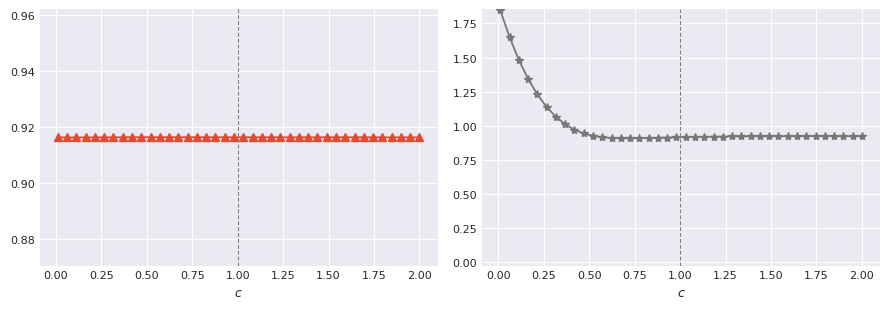

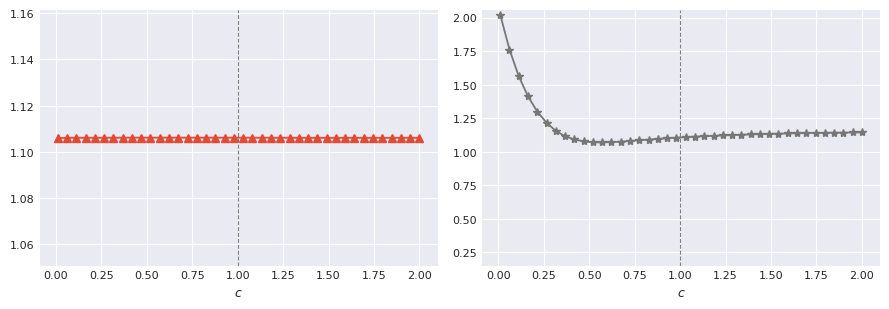

In [ ]:
mult_grid = np.linspace(0.01, 2, 40)

args.scale_t = 1
args.scale_norm = 1
args.dof = 4

# normal error
arr_n, mspe_n, grid = run_linear_sensitivity(
    M=200, d=30, n=10000, n_test=1000, mult_grid=mult_grid, dof=args.dof,
    error_type='normal', err_scale=args.scale_norm,
    intercept=True, standardize=True, truncate=True, n_jobs=200)
np.save('./res_linear/sens_linear_normal.npy', arr_n)
a = plot_linear_sensitivity(
    grid, mspe_n,
    fname='./res_linear/sens_linear_normal.pdf', anchor = 'default')

# t error
arr_t, mspe_t, grid = run_linear_sensitivity(
    M=200, d=30, n=10000, n_test=1000, mult_grid=mult_grid, dof=args.dof,
    error_type='t', err_scale=args.scale_t,
    intercept=True, standardize=True, truncate=True, n_jobs=200)
np.save('./res_linear/sens_linear_t.npy', arr_t)
b = plot_linear_sensitivity(
    grid, mspe_t,
    fname='./res_linear/sens_linear_t.pdf', anchor = 'default')


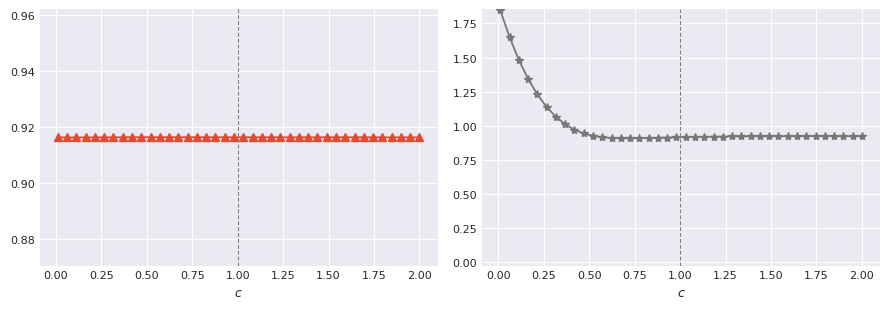

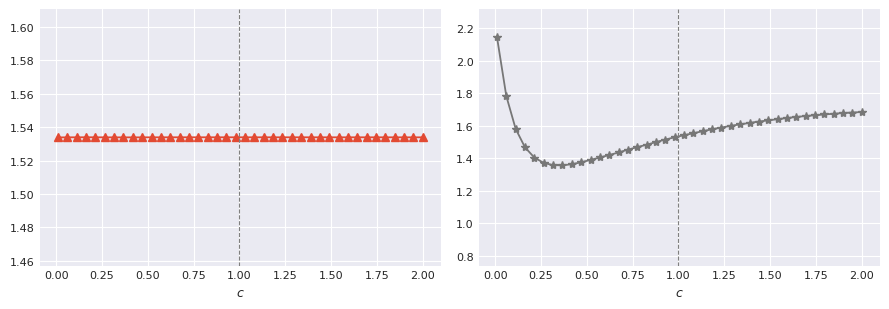

In [68]:
a = plot_linear_sensitivity(
    grid, mspe_n,
    fname='sens_linear_normal.pdf', anchor = 'default')
b = plot_linear_sensitivity(
    grid, mspe_t,
    fname='sens_linear_t.pdf', anchor = 'default')